<a href="https://colab.research.google.com/github/EmmanuelIsaiasGuizarBayardo/NMA-CN-Projects/blob/main/exploratory_FacesHouses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Analysis — FacesHouses (visual-perception read-out)

**Dataset.** Miller ECoG faces/houses (Miller et al., 2015, 2016, 2017): 7 subjects, 2 sessions each. Session 0 is a clean face/house localizer; **session 1 adds graded visual noise and records the subject's behavioral response**, which is what makes the differentiated question possible.

**Framing.** This is a *decoding* dataset — reading perceived category from ventral-temporal cortex. It aligns with the vision/perception **read-out** half of a visual-BCI loop, not with electrical stimulation/encoding. Present it as "decoding visual perception, the read-out component of a vision interface," not as a full prosthetic-vision system.

**Differentiated angle.** Prior groups decoded category (MVPA by noise level) or characterized high-gamma latency. The untouched, engineering-flavored question here: **the decoder's degradation curve vs. the subject's perceptual threshold** — does the noise level where the neural decoder collapses predict the noise level where the human starts making errors? This uses the graded-noise structure the dataset has by design.

**Audit-first discipline.** Before committing, Part A counts trials per category × noise, and Part B confirms face/house decodes above chance with our own pipeline.

## Part A — Structural audit

In [1]:
# @title A1. Retrieve + load faceshouses.npz
import os, requests
import numpy as np

FNAME, URL = "faceshouses.npz", "https://osf.io/argh7/download"
if not os.path.isfile(FNAME):
    r = requests.get(URL); r.raise_for_status()
    open(FNAME, "wb").write(r.content)

alldat = np.load(FNAME, allow_pickle=True)["dat"]
print(f"n_subjects: {len(alldat)}  |  sessions/subject: {len(alldat[0])}")
print("session 0 (localizer) keys:", sorted(alldat[0][0].keys()))
print("session 1 (noisy task) keys:", sorted(alldat[0][1].keys()))

n_subjects: 7  |  sessions/subject: 2
session 0 (localizer) keys: ['Brodmann_Area', 'V', 'gyrus', 'hemisphere', 'lobe', 'locs', 'scale_uv', 'srate', 'stim_id', 't_off', 't_on']
session 1 (noisy task) keys: ['Brodmann_Area', 'V', 'categories', 'gyrus', 'hemisphere', 'key_press', 'lobe', 'locs', 'scale_uv', 'stim_cat', 'stim_id', 'stim_noise', 't_off', 't_on']


In [2]:
# @title A2. Localizer audit (session 0): shapes, channels, house/face balance
import pandas as pd

def audit_localizer(alldat) -> pd.DataFrame:
    """Per-subject structure of the clean localizer. stim_id<=50 house, >50 face."""
    rows = []
    for s, subj in enumerate(alldat):
        dat = subj[0]
        V = dat["V"]; sid = np.asarray(dat["stim_id"]).ravel()
        rows.append({
            "subject": s, "V_shape": V.shape, "V_dtype": str(V.dtype),
            "srate": float(np.squeeze(dat["srate"])), "n_channels": V.shape[1],
            "n_stim": sid.size, "n_house(<=50)": int((sid <= 50).sum()),
            "n_face(>50)": int((sid > 50).sum()),
            "V_MB": round(V.astype("float32").nbytes / 1e6, 1),
        })
    return pd.DataFrame(rows)

loc = audit_localizer(alldat)
pd.set_option("display.max_columns", None, "display.width", 200)
print(loc.to_string(index=False))

 subject      V_shape V_dtype  srate  n_channels  n_stim  n_house(<=50)  n_face(>50)  V_MB
       0 (268400, 41) float16 1000.0          41     300            150          150  44.0
       1 (271360, 50) float16 1000.0          50     300            150          150  54.3
       2 (251240, 39) float16 1000.0          39     300            150          150  39.2
       3 (271400, 60) float16 1000.0          60     300            150          150  65.1
       4 (271400, 58) float16 1000.0          58     300            150          150  63.0
       5 (271400, 39) float16 1000.0          39     300            150          150  42.3
       6 (271400, 58) float16 1000.0          58     300            150          150  63.0


In [3]:
# @title A3. Noisy-task audit (session 1): noise levels, key_press, category x noise balance
def audit_noisy(dat) -> dict:
    """Expose the session-1 structure that the differentiated angle depends on."""
    sc = np.asarray(dat["stim_cat"]).ravel()
    noise = np.asarray(dat["stim_noise"]).ravel()
    kp = np.asarray(dat["key_press"]).ravel()
    cats = [str(c) for c in np.asarray(dat["categories"]).ravel()]
    return {"n_trials": sc.size, "categories": cats,
            "stim_cat_values": sorted(set(sc.tolist())),
            "noise_levels": np.unique(noise).round(3).tolist(),
            "key_press_dtype": str(kp.dtype),
            "key_press_unique(head)": sorted(set(kp.tolist()))[:8],
            "key_press_len==n_trials": kp.size == sc.size}

info = audit_noisy(alldat[1][1])
for k, v in info.items():
    print(f"{k}: {v}")

# category x noise balance for one subject (the class-balance the 'threshold' angle needs)
dat = alldat[1][1]
sc = np.asarray(dat["stim_cat"]).ravel(); noise = np.asarray(dat["stim_noise"]).ravel()
tab = pd.crosstab(pd.Series(noise, name="noise"), pd.Series(sc, name="stim_cat"))
print("\nSubject 1 — trials per (noise x category):")
print(tab.to_string())
print("\nFLAG: high-noise bins tend to be thin -> wide error bars exactly where the "
      "threshold question lives. Quantify per subject before committing.")

n_trials: 630
categories: ["{'1': 'house', '2': 'face'}"]
stim_cat_values: [1, 2]
noise_levels: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
key_press_dtype: int64
key_press_unique(head): []
key_press_len==n_trials: False

Subject 1 — trials per (noise x category):
stim_cat   1   2
noise           
0         15  15
5         15  15
10        15  17
15        15  15
20        15  15
25        15  15
30        15  15
35        15  15
40        15  15
45        15  15
50        15  15
55        15  15
60        15  15
65        15  15
70        15  15
75        15  15
80        15  15
85        15  15
90        15  15
95        15  15
100       15  13

FLAG: high-noise bins tend to be thin -> wide error bars exactly where the threshold question lives. Quantify per subject before committing.


## Part B — Signal sanity & decodability audit (go/no-go)

In [4]:
# @title B1. Shared DSP helpers (notebook-style broadband) + validation note
from scipy import signal

# NB: scipy>=1.8 rejects list cutoffs like butter(3,[50],...); use SCALARS for
# high/low-pass. The original loader used [50]/[10] and breaks on modern Colab.
def broadband_power(V: np.ndarray, fs: float = 1000.0,
                    hp: float = 50.0, lp: float = 10.0) -> np.ndarray:
    """Miller-style broadband: >hp Hz power, lp Hz smoothing, mean-normalized.

    Matches the loader's pipeline (highpass -> square -> lowpass -> /mean),
    which is the signal both Miller papers and the NMA notebook rely on.
    """
    b, a = signal.butter(3, hp, btype="high", fs=fs); V = signal.filtfilt(b, a, V, 0)
    V = np.abs(V) ** 2
    b, a = signal.butter(3, lp, btype="low", fs=fs); V = signal.filtfilt(b, a, V, 0)
    return V / V.mean(0)


def epoch(Vbb: np.ndarray, onsets, trange=np.arange(-200, 400)):
    """Cut windows (ms @1kHz) around onsets; returns (epochs, trange, kept_mask)."""
    onsets = np.asarray(onsets).ravel().astype(int)
    ok = (onsets + trange[0] >= 0) & (onsets + trange[-1] < Vbb.shape[0])
    ts = onsets[ok][:, None] + trange
    return np.reshape(Vbb[ts, :], (int(ok.sum()), len(trange), Vbb.shape[1])), trange, ok


def bb_features(dat, win=(100, 350)):
    """Mean log broadband power in a post-stimulus window per channel -> (X, kept)."""
    Vbb = broadband_power(dat["V"].astype("float32"))
    ep, tr, ok = epoch(Vbb, dat["t_on"])
    m = (tr >= win[0]) & (tr <= win[1])
    return np.log(np.clip(ep[:, m, :].mean(1), 1e-6, None)), ok


def _self_test():
    fs = 1000; x = np.random.default_rng(0).standard_normal((6000, 4)).astype("float32")
    x[1200:1450, 0] += 3 * np.sin(2 * np.pi * 80 * np.arange(250) / fs)  # >50Hz burst
    p = broadband_power(x)
    assert p[1200:1450, 0].mean() > 2 * p[:1000, 0].mean(), "broadband not recovered"
    print("DSP self-test passed (validates pipeline mechanics on a clean burst, "
          "not robustness on real ECoG).")

_self_test()

DSP self-test passed (validates pipeline mechanics on a clean burst, not robustness on real ECoG).


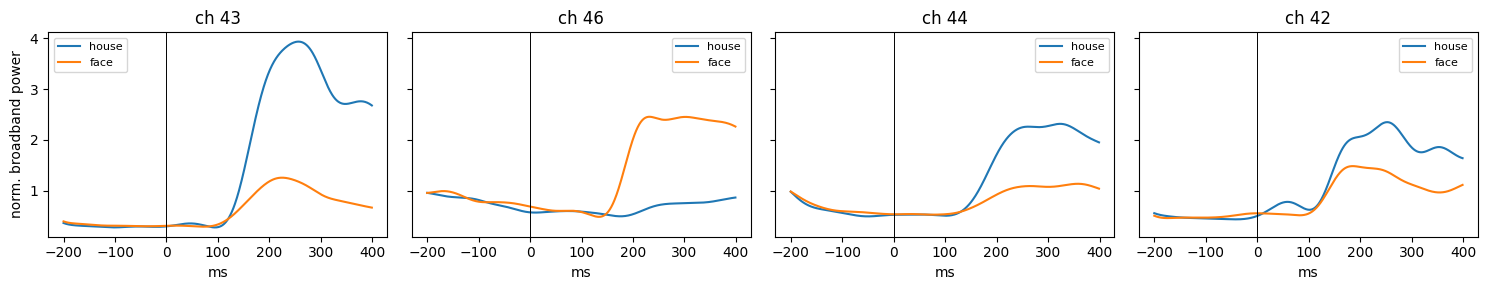

Expected: category-selective channels in ventral temporal cortex (faces vs. houses diverge ~100-300 ms).


In [5]:
# @title B2. Face vs. house broadband — trial-averaged, best channels (validation)
import matplotlib.pyplot as plt

SUBJECT = 1
dat = alldat[SUBJECT][0]                    # localizer
Vbb = broadband_power(dat["V"].astype("float32"))
ep, tr, ok = epoch(Vbb, dat["t_on"])
sid = np.asarray(dat["stim_id"]).ravel()[ok]
is_face = sid > 50
face_m = ep[is_face].mean(0); house_m = ep[~is_face].mean(0)

# rank channels by face-vs-house separation in the response window
win = (tr >= 100) & (tr <= 350)
sep = np.abs(face_m[win].mean(0) - house_m[win].mean(0))
best = np.argsort(-sep)[:4]

fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True)
for ax, ch in zip(axes, best):
    ax.plot(tr, house_m[:, ch], label="house")
    ax.plot(tr, face_m[:, ch], label="face")
    ax.axvline(0, color="k", lw=.7); ax.set_title(f"ch {ch}"); ax.set_xlabel("ms")
    ax.legend(fontsize=8)
axes[0].set_ylabel("norm. broadband power")
plt.tight_layout(); plt.show()
print("Expected: category-selective channels in ventral temporal cortex "
      "(faces vs. houses diverge ~100-300 ms).")

In [6]:
# @title B3. Face vs. house decodability (localizer) — per subject + pooled  [GO/NO-GO]
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def decode_localizer(dat, n_splits=5):
    X, ok = bb_features(dat)
    y = (np.asarray(dat["stim_id"]).ravel()[ok] > 50).astype(int)  # 1=face
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    cv = StratifiedKFold(n_splits, shuffle=True, random_state=0)
    s = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    return float(s.mean()), float(s.std()), len(y)

rows = []
for s in range(len(alldat)):
    acc, sd, n = decode_localizer(alldat[s][0])
    rows.append({"subject": s, "n_trials": n, "acc": round(acc, 3),
                 "sd": round(sd, 3), "chance": 0.5})
res = pd.DataFrame(rows)
print(res.to_string(index=False))
print(f"\nMean face/house accuracy = {res.acc.mean():.3f} (chance 0.5)")
print("GO/NO-GO: if most subjects clear ~0.7+, FacesHouses decodes -> proceed. "
      "If it hovers at chance, stop before committing (this is the AJILE lesson).")

 subject  n_trials   acc    sd  chance
       0       300 0.780 0.045     0.5
       1       300 0.950 0.032     0.5
       2       300 0.973 0.023     0.5
       3       300 0.970 0.032     0.5
       4       300 0.927 0.039     0.5
       5       300 0.910 0.027     0.5
       6       300 0.927 0.037     0.5

Mean face/house accuracy = 0.920 (chance 0.5)
GO/NO-GO: if most subjects clear ~0.7+, FacesHouses decodes -> proceed. If it hovers at chance, stop before committing (this is the AJILE lesson).


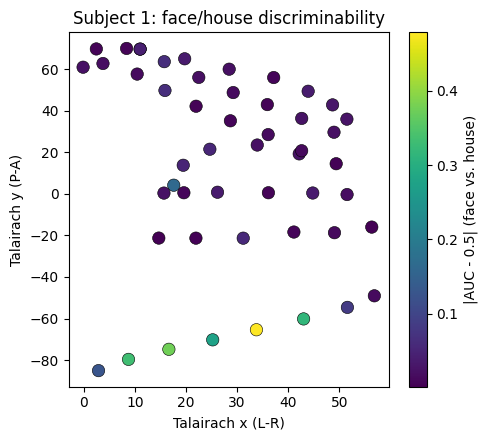

Top channels: [46 44 43 47 45] AUC≈ [0.98 0.12 0.17 0.82 0.22]


In [7]:
# @title B4. Per-channel face/house discriminability map (ventral temporal)
from sklearn.metrics import roc_auc_score

dat = alldat[SUBJECT][0]
X, ok = bb_features(dat)
y = (np.asarray(dat["stim_id"]).ravel()[ok] > 50).astype(int)
auc = np.array([roc_auc_score(y, X[:, c]) for c in range(X.shape[1])])
discr = np.abs(auc - 0.5)
locs = np.asarray(dat["locs"])

plt.figure(figsize=(5, 4.5))
sc = plt.scatter(locs[:, 0], locs[:, 1], c=discr, s=80, cmap="viridis",
                 edgecolor="k", linewidth=.4)
plt.colorbar(sc, label="|AUC - 0.5| (face vs. house)")
plt.xlabel("Talairach x (L-R)"); plt.ylabel("Talairach y (P-A)")
plt.title(f"Subject {SUBJECT}: face/house discriminability"); plt.tight_layout(); plt.show()
print("Top channels:", np.argsort(-discr)[:5], "AUC≈", np.round(auc[np.argsort(-discr)[:5]], 2))

## Part C — Differentiated angle: neural degradation curve vs. perceptual threshold

In [8]:
# @title C1. Neural degradation curve — face/house decode accuracy vs. noise
import ast
from sklearn.model_selection import cross_val_predict

def face_label(dat):
    """Map stim_cat -> face(1)/house(0).

    `categories` is a 1-element array holding a stringified dict such as
    "{'1': 'house', '2': 'face'}"; parse it and pick the code whose name is 'face'.
    """
    sc = np.asarray(dat["stim_cat"]).ravel()
    raw = np.asarray(dat["categories"]).ravel()
    mapping = None
    if raw.size >= 1:
        entry = raw[0]
        mapping = entry if isinstance(entry, dict) else ast.literal_eval(str(entry))
    if isinstance(mapping, dict):
        face_code = int(next(int(k) for k, v in mapping.items()
                             if "face" in str(v).lower()))
    else:
        face_code = max(sorted(set(sc.tolist())))     # fallback: larger code = face
    print(f"categories map={mapping} -> face_code={face_code}")
    return (sc == face_code).astype(int)


def neural_degradation(dat):
    """Per-noise-level CV accuracy of one face/house decoder (broadband features)."""
    X, ok = bb_features(dat)
    y = face_label(dat)[ok]
    noise = np.asarray(dat["stim_noise"]).ravel()[ok]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    pred = cross_val_predict(clf, X, y, cv=cv)
    levels = np.unique(noise)
    acc = np.array([(pred[noise == L] == y[noise == L]).mean() for L in levels])
    n = np.array([int((noise == L).sum()) for L in levels])
    return levels, acc, n, pred, y, noise


SUBJ_C = 5  # must have key presses (S1, S2 are empty); cross-check decoding via B3
levels, n_acc, n_cnt, pred, y, noise = neural_degradation(alldat[SUBJ_C][1])
print("\nneural decode accuracy by noise level:")
for L, a, k in zip(levels, n_acc, n_cnt):
    print(f"  noise={L:.3f}: acc={a:.3f}  n={k}")

categories map={'1': 'house', '2': 'face'} -> face_code=2

neural decode accuracy by noise level:
  noise=0.000: acc=0.633  n=30
  noise=5.000: acc=0.767  n=30
  noise=10.000: acc=0.812  n=32
  noise=15.000: acc=0.767  n=30
  noise=20.000: acc=0.767  n=30
  noise=25.000: acc=0.633  n=30
  noise=30.000: acc=0.700  n=30
  noise=35.000: acc=0.700  n=30
  noise=40.000: acc=0.567  n=30
  noise=45.000: acc=0.600  n=30
  noise=50.000: acc=0.600  n=30
  noise=55.000: acc=0.533  n=30
  noise=60.000: acc=0.600  n=30
  noise=65.000: acc=0.533  n=30
  noise=70.000: acc=0.367  n=30
  noise=75.000: acc=0.467  n=30
  noise=80.000: acc=0.533  n=30
  noise=85.000: acc=0.467  n=30
  noise=90.000: acc=0.633  n=30
  noise=95.000: acc=0.333  n=30
  noise=100.000: acc=0.607  n=28


In [9]:
# @title C2. Perceptual threshold from key_press event TIMES (detection task)
# key_press is a list of button-press TIMES (samples @1kHz), NOT per-trial labels,
# and lengths differ per subject (S1, S2 have none). We map each press to the
# stimulus on screen, infer the target category from low-noise press rates
# (data-driven, no task assumption), and build a detection-accuracy psychometric.
RESP_WINDOW_MS = 1000            # max RT to attribute a press to a stimulus


def responded_per_trial(dat, resp_window: int = RESP_WINDOW_MS) -> np.ndarray:
    """Boolean per trial: a button press fell within resp_window after onset."""
    t_on = np.asarray(dat["t_on"]).ravel().astype(int)
    presses = np.asarray(dat["key_press"]).ravel().astype(int)
    responded = np.zeros(t_on.size, bool)
    if presses.size == 0:
        return responded
    idx = np.searchsorted(t_on, presses, side="right") - 1   # stimulus on at press time
    for p, i in zip(presses, idx):
        if 0 <= i < t_on.size and 0 <= p - t_on[i] <= resp_window:
            responded[i] = True
    return responded


def perceptual_curve(dat):
    """Detection-accuracy psychometric per noise level; target inferred from data.

    Returns (levels, acc, n, responded, is_target) or None if no presses.
    """
    presses = np.asarray(dat["key_press"]).ravel()
    if presses.size == 0:
        print("no key presses for this subject -> no behavioral curve "
              "(exclude from the perceptual-threshold comparison).")
        return None
    noise = np.asarray(dat["stim_noise"]).ravel()
    is_face = face_label(dat).astype(bool)
    resp = responded_per_trial(dat)
    levels = np.unique(noise); lo = levels.min()
    pr_face = resp[is_face & (noise == lo)].mean()
    pr_house = resp[~is_face & (noise == lo)].mean()
    target_is_face = pr_face >= pr_house
    print(f"press rate @ lowest noise: face={pr_face:.2f}, house={pr_house:.2f} "
          f"-> inferred target = {'FACE' if target_is_face else 'HOUSE'}")
    is_target = is_face if target_is_face else ~is_face
    correct = (resp == is_target)          # hit on target trials, correct-reject otherwise
    acc = np.array([correct[noise == L].mean() for L in levels])
    n = np.array([int((noise == L).sum()) for L in levels])
    return levels, acc, n, resp, is_target


beh = perceptual_curve(alldat[SUBJ_C][1])
if beh is not None:
    bl, bacc, bn = beh[0], beh[1], beh[2]
    print("behavioral (detection) accuracy by noise level:")
    for L, a, k in zip(bl, bacc, bn):
        print(f"  noise={L:.3f}: acc={a:.3f} (n={k})")

categories map={'1': 'house', '2': 'face'} -> face_code=2
press rate @ lowest noise: face=0.93, house=0.33 -> inferred target = FACE
behavioral (detection) accuracy by noise level:
  noise=0.000: acc=0.800 (n=30)
  noise=5.000: acc=0.867 (n=30)
  noise=10.000: acc=0.969 (n=32)
  noise=15.000: acc=1.000 (n=30)
  noise=20.000: acc=0.900 (n=30)
  noise=25.000: acc=0.867 (n=30)
  noise=30.000: acc=0.767 (n=30)
  noise=35.000: acc=0.700 (n=30)
  noise=40.000: acc=0.700 (n=30)
  noise=45.000: acc=0.533 (n=30)
  noise=50.000: acc=0.600 (n=30)
  noise=55.000: acc=0.467 (n=30)
  noise=60.000: acc=0.467 (n=30)
  noise=65.000: acc=0.667 (n=30)
  noise=70.000: acc=0.600 (n=30)
  noise=75.000: acc=0.433 (n=30)
  noise=80.000: acc=0.500 (n=30)
  noise=85.000: acc=0.400 (n=30)
  noise=90.000: acc=0.500 (n=30)
  noise=95.000: acc=0.333 (n=30)
  noise=100.000: acc=0.429 (n=28)


In [10]:
# @title C3. Permutation null for the degradation curve (per noise level)
# Shuffle labels, rebuild the per-level CV accuracy -> empirical chance band per
# noise level. Matters most for thin high-noise bins where finite-n variance is
# large. ~30-60 s; lower N_PERM_DEG if Colab is slow.
from numpy.random import default_rng

N_PERM_DEG = 1000


def degradation_null(dat, obs_acc, levels, n_perm: int = N_PERM_DEG, seed: int = 0):
    """Per-noise-level null 95% CI and one-sided p-value (observed >= null)."""
    X, ok = bb_features(dat)
    y = face_label(dat)[ok]
    noise = np.asarray(dat["stim_noise"]).ravel()[ok]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    rng = default_rng(seed)
    null = np.empty((n_perm, len(levels)))
    for i in range(n_perm):
        yp = rng.permutation(y)
        pred = cross_val_predict(clf, X, yp, cv=cv)
        null[i] = [(pred[noise == L] == yp[noise == L]).mean() for L in levels]
    lo, hi = np.percentile(null, [2.5, 97.5], axis=0)
    p = np.array([(np.sum(null[:, j] >= obs_acc[j]) + 1) / (n_perm + 1)
                  for j in range(len(levels))])
    return lo, hi, p


null_lo, null_hi, p_lvl = degradation_null(alldat[SUBJ_C][1], n_acc, levels)
print("per-noise-level significance (neural acc vs. permutation null):")
for j, L in enumerate(levels):
    star = " *" if p_lvl[j] < 0.05 else ""
    print(f"  noise={L:.3f}: acc={n_acc[j]:.3f} (n={n_cnt[j]})  "
          f"null95=[{null_lo[j]:.3f}, {null_hi[j]:.3f}]  p={p_lvl[j]:.3f}{star}")

sig = p_lvl < 0.05
neural_thr = float(levels[sig].max()) if sig.any() else None
print()
print(f"Neural collapse: decoding is significant up to noise={neural_thr}; "
      "above that the decoder re-enters the chance band.")

categories map={'1': 'house', '2': 'face'} -> face_code=2
per-noise-level significance (neural acc vs. permutation null):
  noise=0.000: acc=0.633 (n=30)  null95=[0.333, 0.667]  p=0.117
  noise=5.000: acc=0.767 (n=30)  null95=[0.300, 0.667]  p=0.004 *
  noise=10.000: acc=0.812 (n=32)  null95=[0.312, 0.656]  p=0.001 *
  noise=15.000: acc=0.767 (n=30)  null95=[0.300, 0.667]  p=0.005 *
  noise=20.000: acc=0.767 (n=30)  null95=[0.333, 0.700]  p=0.006 *
  noise=25.000: acc=0.633 (n=30)  null95=[0.333, 0.667]  p=0.097
  noise=30.000: acc=0.700 (n=30)  null95=[0.333, 0.667]  p=0.012 *
  noise=35.000: acc=0.700 (n=30)  null95=[0.333, 0.667]  p=0.024 *
  noise=40.000: acc=0.567 (n=30)  null95=[0.333, 0.667]  p=0.288
  noise=45.000: acc=0.600 (n=30)  null95=[0.333, 0.667]  p=0.179
  noise=50.000: acc=0.600 (n=30)  null95=[0.333, 0.667]  p=0.191
  noise=55.000: acc=0.533 (n=30)  null95=[0.333, 0.700]  p=0.412
  noise=60.000: acc=0.600 (n=30)  null95=[0.333, 0.667]  p=0.172
  noise=65.000: acc=0.5

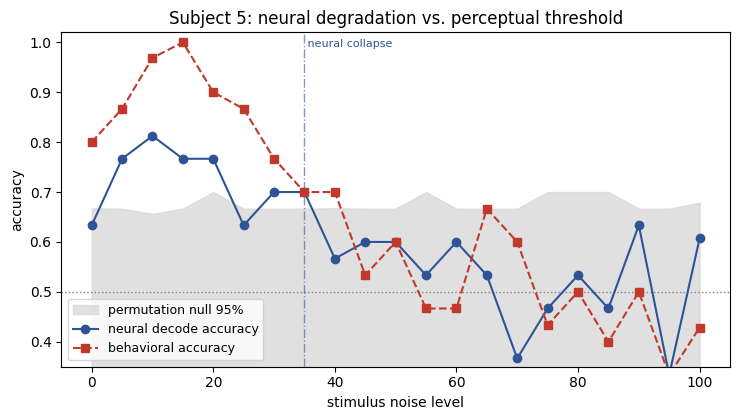

Read-out limit: the noise where the neural curve re-enters the null band (neural collapse) vs. where behavioral accuracy falls. Their alignment across subjects IS the finding — the read-out ceiling of a vision interface.


In [11]:
# @title C4. Overlay — decoder collapse vs. perceptual threshold (with null band)
plt.figure(figsize=(7.5, 4.3))
plt.fill_between(levels, null_lo, null_hi, color="0.85", alpha=.8,
                 label="permutation null 95%", zorder=0)
plt.plot(levels, n_acc, "o-", color="#2E5496", label="neural decode accuracy", zorder=3)
if beh is not None:
    plt.plot(bl, bacc, "s--", color="#c0392b", label="behavioral accuracy", zorder=3)
plt.axhline(0.5, ls=":", color="0.5", lw=1)
for j, L in enumerate(levels):                       # flag thin bins
    if n_cnt[j] < 15:
        plt.annotate(f"n={n_cnt[j]}", (L, n_acc[j]), fontsize=7, color="0.4",
                     textcoords="offset points", xytext=(0, 7))
if neural_thr is not None:
    plt.axvline(neural_thr, ls="-.", color="#2E5496", lw=1, alpha=.6)
    plt.text(neural_thr, 0.99, " neural collapse", fontsize=8, color="#2E5496")
plt.xlabel("stimulus noise level"); plt.ylabel("accuracy"); plt.ylim(0.35, 1.02)
plt.title(f"Subject {SUBJ_C}: neural degradation vs. perceptual threshold")
plt.legend(fontsize=9, loc="lower left"); plt.tight_layout(); plt.show()
print("Read-out limit: the noise where the neural curve re-enters the null band "
      "(neural collapse) vs. where behavioral accuracy falls. Their alignment "
      "across subjects IS the finding — the read-out ceiling of a vision interface.")

## Part D — Go/no-go & framing notes

**Decodability (from B3).** Fill in: mean face/house accuracy `___` (chance 0.5), subjects clearing 0.7 `___/7`. If solid, the project floor exists; if not, stop here.

**Class balance for the angle (from A3/C1).** High-noise bins are thin — record min trials per (category × noise) cell. If lateral/high-noise cells are too small for per-subject curves, pool subjects (aligning by noise level, not channel).

**Honest scope.** Read-out only, no stimulation. Frame as "decoding visual perception, the read-out half of a vision interface." Aligns with the Next-Gen Neuroengineer role on the vision/perception axis, *not* on the encoding/stimulation axis (its most distinctive requirement).

**Cost of the pivot.** This restarts the verification work MotorImagery already has (audit, nulls, one-pager). Worth it only if the team genuinely prefers the vision axis, not merely to chase a posting.

**Suggested next steps.** (1) Add a permutation null to the degradation curve per noise level (reuse the A10/B10 pattern). (2) Fit each subject's behavioral psychometric threshold and the neural threshold, then test whether they correlate across subjects — that correlation *is* the finding.

**References.** Miller, K. J., Hermes, D., Witthoft, N., Rao, R. P. N., & Ojemann, J. G. (2015). *J. Neurophysiol., 114*(1), 256–263. · Miller, K. J., Schalk, G., Hermes, D., Ojemann, J. G., & Rao, R. P. N. (2016). *PLOS Comput. Biol., 12*(1), e1004660. · Miller, K. J., Hermes, D., Pestilli, F., Wig, G. S., & Ojemann, J. G. (2017). *J. Neurophysiol., 118*(5), 2614–2627.
